**2. MİMARİ: Mesa + Karar Teorisi → Strateji**


Mimari 2'yi (Karar Teorisi → Strateji → Aksiyon) Mesa 3.1.5 kullanarak yapacağız.

Yani: her ajan bir Mesa agent olacak, simülasyon içinde karar verip aksiyona geçecek.

Yine her ajan kendi karar teorisini değiştirip yeni strateji seçecek.

Önce basit bir yapı çizelim:

**Yapı**

Model: Birkaç ajan içeriyor.

Ajanlar:

-Bir DecisionTheory seçiyor.

-Teoriden bir Strategy üretiyor.

-Stratejiyi uyguluyor.

Karar Teorisi: Örneğin Expected Utility veya Prospect Theory.

Strateji: Risk-Seeking ya da Conservative yatırım gibi.

In [1]:

!pip install mesa[rec]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.8/265.8 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.8 MB/s eta 0:00:00


In [2]:

!pip install mesa[rec]

In [3]:

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

In [4]:
# 1. Karar Teorileri

class DecisionTheory:
    def select_strategy(self, agent_state):
        raise NotImplementedError

class ExpectedUtilityTheory(DecisionTheory):
    def select_strategy(self, agent_state):
        if agent_state['risk_aversion'] > 0.5:
            return ConservativeStrategy()
        else:
            return RiskSeekingStrategy()

class ProspectTheory(DecisionTheory):
    def select_strategy(self, agent_state):
        if agent_state['recent_loss'] > 0:
            return ConservativeStrategy()
        else:
            return RiskSeekingStrategy()





In [5]:
# 2. Stratejiler

class Strategy:
    def act(self, agent_state):
        raise NotImplementedError

class RiskSeekingStrategy(Strategy):
    def act(self, agent_state):
        return "Invest in High-Risk Asset"

class ConservativeStrategy(Strategy):
    def act(self, agent_state):
        return "Invest in Safe Asset"




In [6]:
# 3. Ajan (Mesa Agent)

import random

class DecisionAgent(mesa.Agent):
    def __init__(self, model, decision_theory):
        super().__init__(model)
        self.decision_theory = decision_theory
        self.strategy = None
        self.state = {
            'risk_aversion': self.random.random(),
            'recent_loss': self.random.randint(0, 1)  # 0 veya 1
        }

    def step(self):
        # Stratejiyi karar teorisinden seç
        self.strategy = self.decision_theory.select_strategy(self.state)
        # Stratejiyi uygula
        action = self.strategy.act(self.state)
        print(f"Ajan {self.unique_id} → Durum: {self.state} → Aksiyon: {action}")

        # Belirli bir olasılıkla karar teorisini değiştir
        if self.random.random() < 0.2:
            self.mutate_decision_theory()

    def mutate_decision_theory(self):
        old_theory = self.decision_theory.__class__.__name__
        if isinstance(self.decision_theory, ExpectedUtilityTheory):
            self.decision_theory = ProspectTheory()
        else:
            self.decision_theory = ExpectedUtilityTheory()
        print(f"Ajan {self.unique_id} karar teorisini değiştirdi: {old_theory} → {self.decision_theory.__class__.__name__}")


In [13]:
# 4. Model (Mesa Model)

import random
class DecisionModel(mesa.Model):
    def __init__(self, num_agents):
        super().__init__()

        self.num_agents = num_agents


        # Ajanları oluştur
        for i in range(self.num_agents):
            if self.random.random() < 0.5:
                theory = ExpectedUtilityTheory()
            else:
                theory = ProspectTheory()
            agent = DecisionAgent(self, theory)
            self.agents.add(agent)

    def step(self):
        self.agents.do("step")


In [14]:
# 5. Simülasyonu Çalıştırma

model = DecisionModel(num_agents=5)

for i in range(10):  # 10 adım çalıştır
    print(f"\n--- Adım {i+1} ---")
    model.step()



--- Adım 1 ---
Ajan 1 → Durum: {'risk_aversion': 0.19500426227511702, 'recent_loss': 1} → Aksiyon: Invest in High-Risk Asset
Ajan 2 → Durum: {'risk_aversion': 0.7311644817313525, 'recent_loss': 0} → Aksiyon: Invest in Safe Asset
Ajan 3 → Durum: {'risk_aversion': 0.7074083957304184, 'recent_loss': 1} → Aksiyon: Invest in Safe Asset
Ajan 4 → Durum: {'risk_aversion': 0.17203000836400872, 'recent_loss': 0} → Aksiyon: Invest in High-Risk Asset
Ajan 5 → Durum: {'risk_aversion': 0.09327979792898067, 'recent_loss': 1} → Aksiyon: Invest in High-Risk Asset

--- Adım 2 ---
Ajan 1 → Durum: {'risk_aversion': 0.19500426227511702, 'recent_loss': 1} → Aksiyon: Invest in High-Risk Asset
Ajan 2 → Durum: {'risk_aversion': 0.7311644817313525, 'recent_loss': 0} → Aksiyon: Invest in Safe Asset
Ajan 2 karar teorisini değiştirdi: ExpectedUtilityTheory → ProspectTheory
Ajan 3 → Durum: {'risk_aversion': 0.7074083957304184, 'recent_loss': 1} → Aksiyon: Invest in Safe Asset
Ajan 4 → Durum: {'risk_aversion': 0.17

**Bu yapının Özellikleri**

✅ Ajanlar karar teorisi seçiyor.

✅ Karar teorisi ajanı bir strateji seçmeye yönlendiriyor.

✅ Strateji ajanı bir aksiyon yapmaya yönlendiriyor.

✅ Ajanlar zamanla karar teorilerini değiştirebiliyor

Aşağıda yapılacaklar:

Karar teorisi değişimlerini bir kurala bağlamak

Stratejileri çeşitlendirmek

Modelin çıktısını toplamak (DataCollector ile)

Grafikle göstermek


**Geliştirme Planı**

Karar Teorisi Değişim Kuralı ekle:

Rasgele değil, ajanın performansına veya state'ine göre karar teorisi değişsin.

Örneğin: "kayıp yaşarsa karar teorisi değiştirme şansı artsın".

Strateji Çeşitlendirme:

Şu anda iki strateji vardı: RiskSeeking ve Conservative.

İki yeni strateji daha ekleyeceğiz: örneğin BalancedStrategy ve OpportunisticStrategy.

DataCollector:

Model çalışırken ajanların hangi karar teorisini ve hangi stratejiyi kullandığını toplayalım.

Grafik:

Karar teorilerinin ve stratejilerin zamana göre değişimini grafikle gösterelim.

In [15]:
"""1. Karar Teorisi Değişim Kuralı
Kural:

Eğer ajan son 3 adımda üst üste kayıp yaşarsa (recent_loss == 1), karar teorisini değiştirsin.

Agent'ı Güncelliyoruz:"""

from collections import deque

class DecisionAgent(mesa.Agent):
    def __init__(self, model, decision_theory):
        super().__init__(model)
        self.decision_theory = decision_theory
        self.strategy = None
        self.state = {
            'risk_aversion': self.random.random(),
            'recent_loss': self.random.randint(0, 1),
        }
        self.loss_history = deque(maxlen=3)  # Son 3 adımı tutacağız

    def step(self):
        # Strateji seçimi
        self.strategy = self.decision_theory.select_strategy(self.state)
        action = self.strategy.act(self.state)
        print(f"Ajan {self.unique_id} → Durum: {self.state} → Aksiyon: {action}")

        # State güncelle
        self.state['recent_loss'] = self.random.randint(0, 1)  # Simülasyon için rasgele yeni kayıp
        self.loss_history.append(self.state['recent_loss'])

        # Değişim kuralı: Son 3 adımda 2 veya daha fazla kayıp varsa karar teorisi değiştir
        if sum(self.loss_history) >= 2:
            self.mutate_decision_theory()

    def mutate_decision_theory(self):
        old_theory = self.decision_theory.__class__.__name__
        if isinstance(self.decision_theory, ExpectedUtilityTheory):
            self.decision_theory = ProspectTheory()
        else:
            self.decision_theory = ExpectedUtilityTheory()
        print(f"Ajan {self.unique_id} karar teorisini değiştirdi: {old_theory} → {self.decision_theory.__class__.__name__}")


"""Artık ajanlar daha akıllı değişiyor! (Üst üste kayıplar olunca karar teorisini değiştiriyorlar.)"""

'Artık ajanlar daha akıllı değişiyor! (Üst üste kayıplar olunca karar teorisini değiştiriyorlar.)'

In [16]:
"""2. Stratejileri Çeşitlendiriyoruz- Yeni Strateji Sınıfları"""

class BalancedStrategy(Strategy):
    def act(self, agent_state):
        return "Invest in a Balanced Portfolio"

class OpportunisticStrategy(Strategy):
    def act(self, agent_state):
        if agent_state['risk_aversion'] < 0.3:
            return "Chase High Volatility Assets"
        else:
            return "Stay in Cash"




In [18]:
"""Karar Teorilerini Güncelliyoruz (Strateji seçimini çeşitlendirmek için):"""

class ExpectedUtilityTheory(DecisionTheory):
    def select_strategy(self, agent_state):
        if agent_state['risk_aversion'] > 0.7:
            return ConservativeStrategy()
        elif agent_state['risk_aversion'] < 0.3:
            return RiskSeekingStrategy()
        else:
            return BalancedStrategy()

class ProspectTheory(DecisionTheory):
    def select_strategy(self, agent_state):
        if agent_state['recent_loss'] > 0:
            return ConservativeStrategy()
        elif agent_state['risk_aversion'] < 0.4:
            return OpportunisticStrategy()
        else:
            return BalancedStrategy()


# Artık 4 stratejimiz var:

# RiskSeeking

# Conservative

# Balanced

# Opportunistic"""

In [24]:
"""3. DataCollector ile Veri Toplama- Modelin içine şu DataCollector'ı ekliyoruz:"""

from mesa.datacollection import DataCollector

class DecisionModel(mesa.Model):
    def __init__(self, num_agents):
        super().__init__()
        self.num_agents = num_agents


        for i in range(self.num_agents):
            theory = ExpectedUtilityTheory() if self.random.random() < 0.5 else ProspectTheory()
            agent = DecisionAgent(self, theory)
            self.agents.add(agent)

        self.datacollector = DataCollector(
            agent_reporters={
                "DecisionTheory": lambda a: a.decision_theory.__class__.__name__,
                "Strategy": lambda a: a.strategy.__class__.__name__ if a.strategy else None,
            }
        )

    def step(self):
        self.datacollector.collect(self)
        self.agents.do("step")


# Her ajan için: Karar teorisi Strateji kaydediliyor.

In [25]:
"""4. Grafikle Gösterelim
Simülasyonu çalıştırıp sonra ajan verilerini çıkarıp grafik çizelim.

Simülasyonu Çalıştır:"""


model = DecisionModel(num_agents=10)

for i in range(50):  # 50 adım
    model.step()

agent_data = model.datacollector.get_agent_vars_dataframe()


Ajan 1 → Durum: {'risk_aversion': 0.4274192193018702, 'recent_loss': 1} → Aksiyon: Invest in a Balanced Portfolio
Ajan 2 → Durum: {'risk_aversion': 0.2847636910490091, 'recent_loss': 0} → Aksiyon: Chase High Volatility Assets
Ajan 3 → Durum: {'risk_aversion': 0.479130553380659, 'recent_loss': 1} → Aksiyon: Invest in a Balanced Portfolio
Ajan 4 → Durum: {'risk_aversion': 0.8481192669748577, 'recent_loss': 0} → Aksiyon: Invest in a Balanced Portfolio
Ajan 5 → Durum: {'risk_aversion': 0.6640203449931724, 'recent_loss': 0} → Aksiyon: Invest in a Balanced Portfolio
Ajan 6 → Durum: {'risk_aversion': 0.44289843446632293, 'recent_loss': 0} → Aksiyon: Invest in a Balanced Portfolio
Ajan 7 → Durum: {'risk_aversion': 0.615981297740335, 'recent_loss': 0} → Aksiyon: Invest in a Balanced Portfolio
Ajan 8 → Durum: {'risk_aversion': 0.015150425232493547, 'recent_loss': 1} → Aksiyon: Invest in High-Risk Asset
Ajan 9 → Durum: {'risk_aversion': 0.4810828368760066, 'recent_loss': 0} → Aksiyon: Invest in a

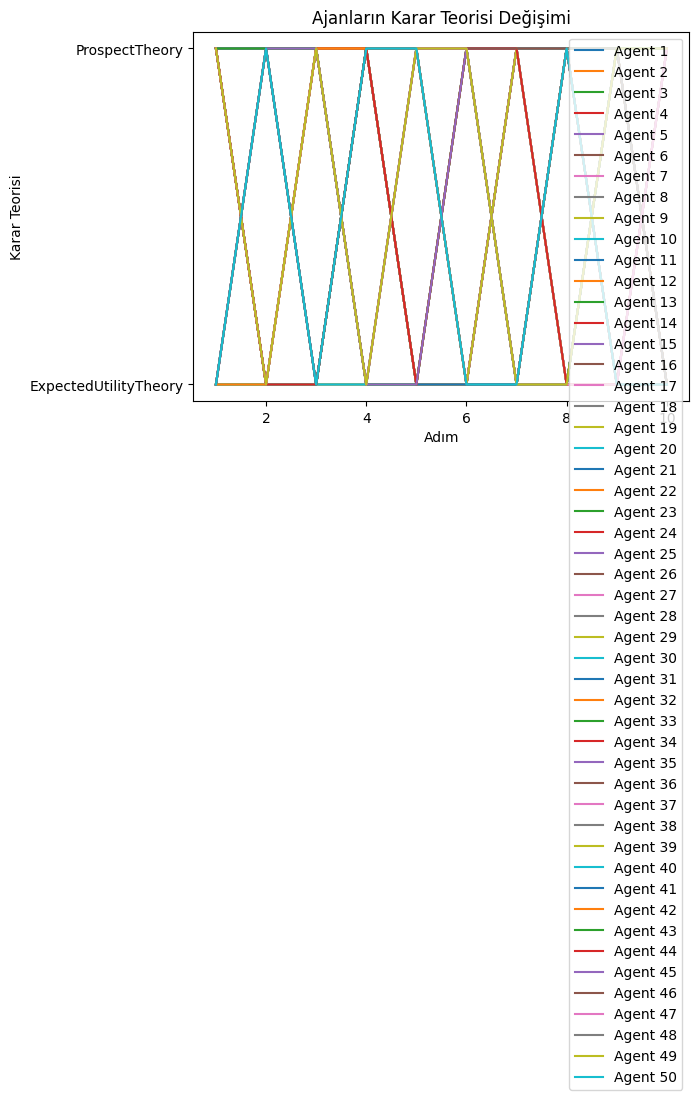

In [26]:
"""Grafik Çizimi:"""

import matplotlib.pyplot as plt

# Karar Teorisi Değişimi
for agent_id in agent_data.index.get_level_values(0).unique():
    agent_series = agent_data.xs(agent_id)
    plt.plot(agent_series.index, agent_series['DecisionTheory'], label=f"Agent {agent_id}")

plt.title("Ajanların Karar Teorisi Değişimi")
plt.xlabel("Adım")
plt.ylabel("Karar Teorisi")
plt.legend()
plt.show()


ConversionError: Failed to convert value(s) to axis units: array([None, None, None, None, None, None, None, None, None, None],
      dtype=object)

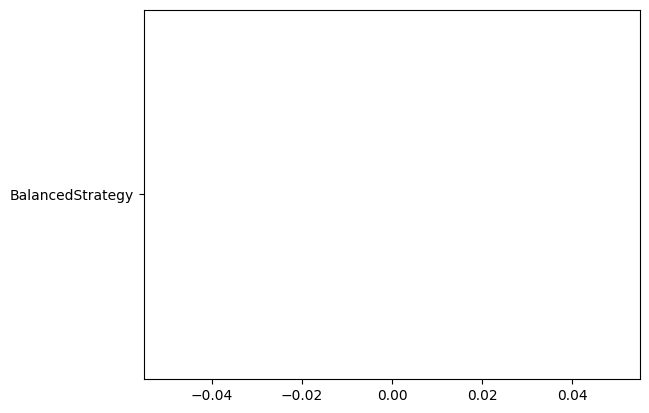

In [27]:
# Strateji Değişimi
for agent_id in agent_data.index.get_level_values(0).unique():
    agent_series = agent_data.xs(agent_id)
    plt.plot(agent_series.index, agent_series['Strategy'], label=f"Agent {agent_id}")

plt.title("Ajanların Strateji Değişimi")
plt.xlabel("Adım")
plt.ylabel("Strateji")
plt.legend()
plt.show()

"""Böylece her ajan için hangi adımda hangi karar teorisi ve hangi strateji kullandığını görebileceğiz."""

***Adım | Yapılan***

1       | Karar teorisi değişim kuralı eklendi

2       | Stratejiler çeşitlendirildi

3       | DataCollector ile veri toplandı

4       | Grafikle zamana bağlı değişimler gösterildi